# Looping Graph — Higher / Lower Guessing Game

An automatic binary-search guesser. The graph picks a random target (1–20) and keeps guessing until it finds the number or exhausts 7 attempts.

In [1]:
from typing import TypedDict, Literal
import random
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Markdown, Image

load_dotenv()

True

In [2]:
class State(TypedDict):
    lower_bound: int
    upper_bound: int
    target: int
    guess: int
    hint: str
    attempts: int
    max_attempts: int
    message: str

In [3]:
def initialize(state: State) -> State:
    """Seed the game: bounds 1–20, random target, zero attempts."""
    return {
        "lower_bound": 1,
        "upper_bound": 20,
        "target": random.randint(1, 20),
        "attempts": 0,
        "max_attempts": 7,
        "message": "",
    }


def make_guess(state: State) -> State:
    """Binary-search midpoint between current bounds."""
    guess = (state["lower_bound"] + state["upper_bound"]) // 2
    return {
        "guess": guess,
        "attempts": state["attempts"] + 1,
    }


def give_hint(state: State) -> State:
    """Compare guess to target — returns 'higher', 'lower', or 'correct'."""
    guess = state["guess"]
    target = state["target"]
    if guess == target:
        return {"hint": "correct"}
    return {"hint": "higher" if guess < target else "lower"}


def adjust_bounds(state: State) -> State:
    """Narrow the search interval based on the hint."""
    hint = state["hint"]
    guess = state["guess"]
    lower = state["lower_bound"]
    upper = state["upper_bound"]
    if hint == "higher":
        lower = guess + 1
    elif hint == "lower":
        upper = guess - 1
    return {"lower_bound": lower, "upper_bound": upper}


def end_success(state: State) -> State:
    return {
        "message": f"Correct! The number was {state['target']}. Guessed in {state['attempts']} attempt(s)."
    }


def end_failure(state: State) -> State:
    return {
        "message": f"Failed to guess {state['target']} in {state['max_attempts']} attempts. Last guess was {state['guess']}."
    }

In [4]:
def decide_route(state: State) -> Literal["end_success", "end_failure", "adjust_bounds"]:
    """Conditional edge: correct guess → success, out of attempts → failure, otherwise keep narrowing."""
    if state["hint"] == "correct":
        return "end_success"
    if state["attempts"] >= state["max_attempts"]:
        return "end_failure"
    return "adjust_bounds"

In [5]:
graph = StateGraph(State)

# register nodes
graph.add_node("initialize", initialize)
graph.add_node("make_guess", make_guess)
graph.add_node("give_hint", give_hint)
graph.add_node("adjust_bounds", adjust_bounds)
graph.add_node("end_success", end_success)
graph.add_node("end_failure", end_failure)

# start → init
graph.add_edge(START, "initialize")

# guessing loop
graph.add_edge("initialize", "make_guess")
graph.add_edge("make_guess", "give_hint")

# conditional: correct / maxed / keep guessing
graph.add_conditional_edges(
    "give_hint",
    decide_route,
    {
        "end_success": "end_success",
        "end_failure": "end_failure",
        "adjust_bounds": "adjust_bounds",
    },
)

# loop back
graph.add_edge("adjust_bounds", "make_guess")

# terminal
graph.add_edge("end_success", END)
graph.add_edge("end_failure", END)

app = graph.compile()

In [6]:
mermaid_code = app.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	initialize(initialize)
	make_guess(make_guess)
	give_hint(give_hint)
	adjust_bounds(adjust_bounds)
	end_success(end_success)
	end_failure(end_failure)
	__end__([<p>__end__</p>]):::last
	__start__ --> initialize;
	adjust_bounds --> make_guess;
	give_hint -.-> adjust_bounds;
	give_hint -.-> end_failure;
	give_hint -.-> end_success;
	initialize --> make_guess;
	make_guess --> give_hint;
	end_failure --> __end__;
	end_success --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

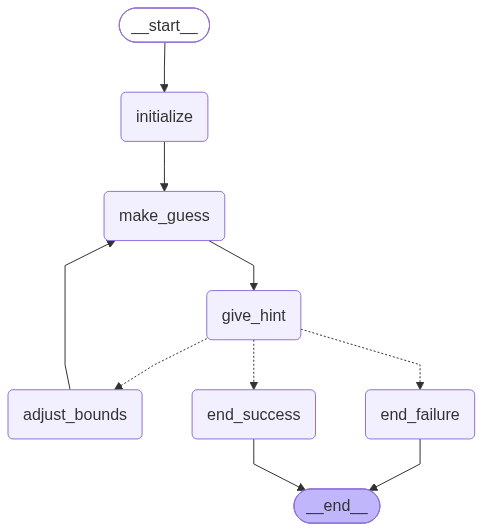

In [7]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("PNG rendering not available — Mermaid diagram above works.")

In [8]:
result = app.invoke({})
print(result["message"])

Correct! The number was 15. Guessed in 2 attempt(s).


In [9]:
# Run multiple rounds to demonstrate the guesser works
for i in range(5):
    r = app.invoke({})
    print(f"Round {i+1}: {r['message']}")

Round 1: Correct! The number was 7. Guessed in 3 attempt(s).
Round 2: Correct! The number was 1. Guessed in 4 attempt(s).
Round 3: Correct! The number was 13. Guessed in 4 attempt(s).
Round 4: Correct! The number was 7. Guessed in 3 attempt(s).
Round 5: Correct! The number was 11. Guessed in 4 attempt(s).
